# Multi-layer perceptron and language models

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

## Data

We are going to train a model that works on characters using a dataset of names called `names.txt` taken from Karpathy's tutorial called `makemore` which is available on youtube.

https://www.youtube.com/watch?v=TCH_1BHY58I

In [4]:
words = open('names.txt', 'r').read().splitlines()
words = [w.strip() for w in words] # remove any space chars
words = [w for w in words if w] # remove any empty strings

Let's look at the first 10 words in the dataset.

In [5]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [14]:
'danny' in words

True

Let's check how many words in the dataset.

In [15]:
len(words)

32033

Let's find the shortest word in the dataset.

In [16]:
min_word = min(words, key=len) # argmin
print(min_word, len(min_word))

an 2


Let's find the longest word in the dataset.

In [17]:
max_word = max(words, key=len) # argmax
print(max_word, len(max_word))

muhammadibrahim 15


### Create a dataset

Add a special character `.` for padding first and last char in a word. There will be 26 chars plus the special char `.` in the vocabulary.

In [19]:
vocab = ['.'] + sorted(list(set([c for w in words for c in w])))
stoi = {s:i for i,s in enumerate(vocab)}
itos = {i:s for s,i in stoi.items()}
len(vocab)

27

The first element of `vocab` is the padding char `.`:

In [21]:
vocab[0]

'.'

## Baseline bigram model

To visualize the data let's plot the bigram statistics for this dataset.

In [22]:
N = torch.zeros((len(vocab), len(vocab)), dtype=torch.int32)

In [23]:
N.size()

torch.Size([27, 27])

In [24]:
def get_bigrams(words):
    for w in words:
        chars = ['.'] + list(w) + ['.']
        for c1, c2 in zip(chars, chars[1:]):
            yield(stoi[c1], stoi[c2])

In [25]:
for idx1, idx2 in get_bigrams(words):
    N[idx1, idx2] += 1

Let's visualize the bigram statistics.

(-0.5, 26.5, 26.5, -0.5)

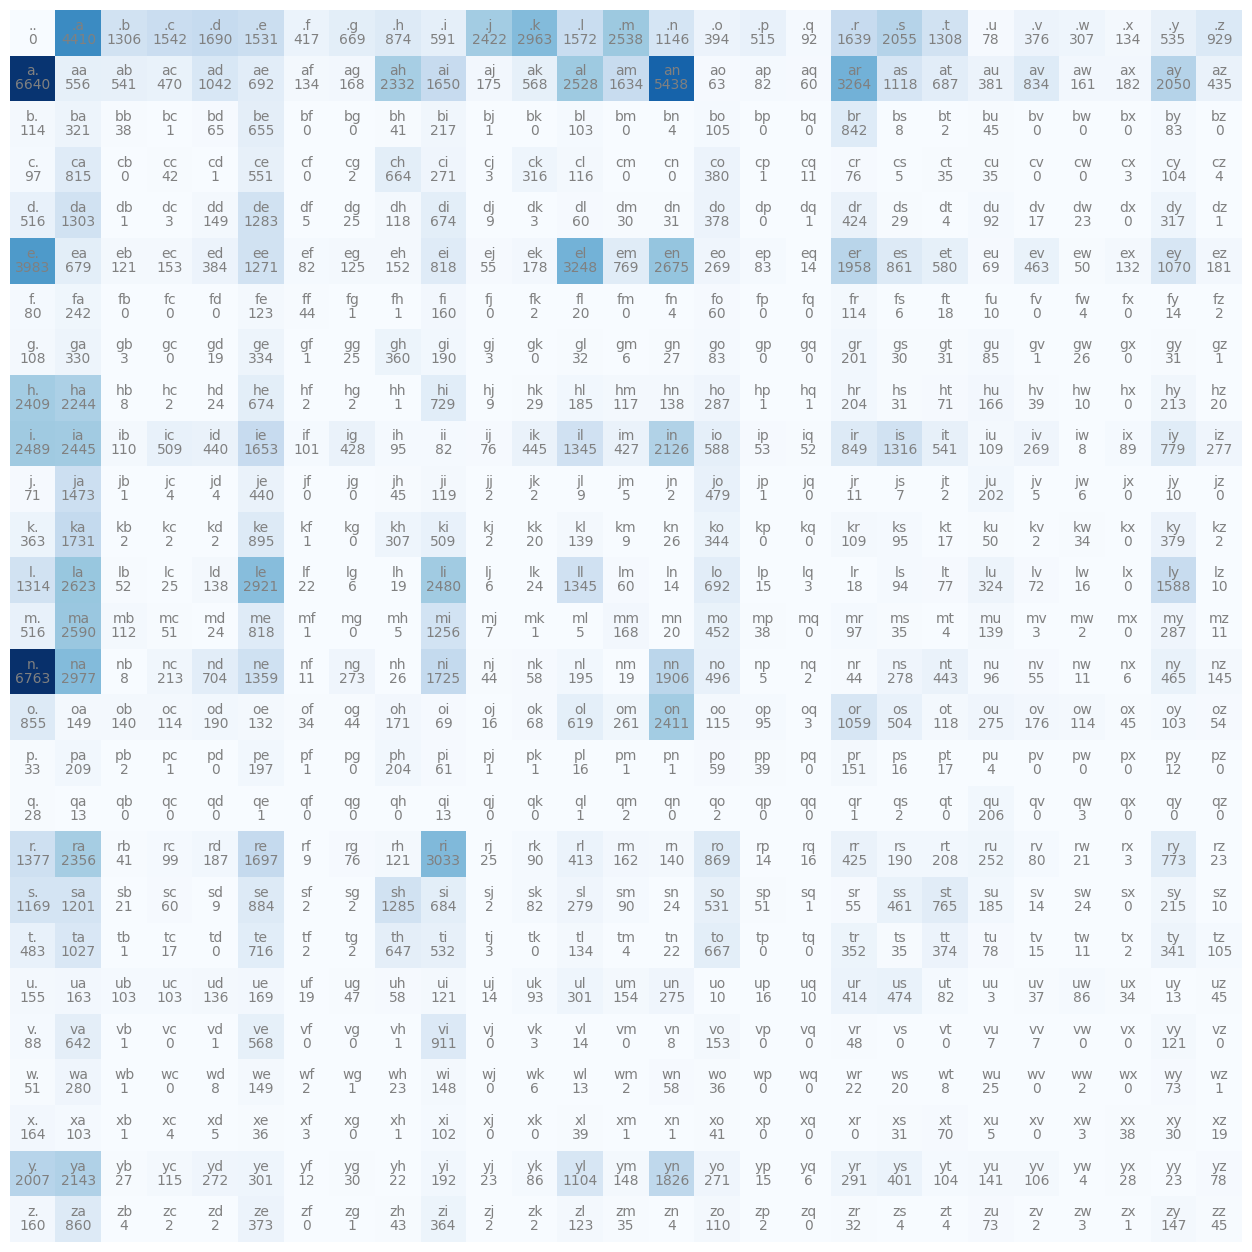

In [26]:
# using Andrej Karpathy's nice way to plot bigram statistics
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(len(vocab)):
    for j in range(len(vocab)):
        plt.text(j, i, itos[i] + itos[j], ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis('off')

We can also "visualize" the bigram statistics by sampling from a distribution created from these counts.

First we convert the raw counts into a conditional probability $p(c2 | c1)$ by normalizing each row of the count matrix.

In [27]:
p = N.float()
for i in range(len(vocab)):
    p[i] = p[i] / sum(p[i])

sum(p[0])

tensor(1.)

In [32]:
p = N.float()
p = p / p.sum(1, keepdim=True) # keepdim=True is important! learn about broadcasting in Pytorch

sum(p[0]) # try: p.sum(1, keepdim=True)

tensor(1.)

In [33]:
p.size()

torch.Size([27, 27])

We then sample some words from the bigram probability distribution in `p`. 

Use `torch.Generator` to set a manual seed to generate the same sequence random samples each time.

Use `torch.multinomial` to sample from a row of the `p` tensor. Recall that we had set each element of row `p[i]` to be the probability distribution of $p(j|i)$ for each character `j` in the vocabulary. We start with a "prompt" character index `i` and then sample a new character from that row and continue in a loop until we reach the padding character `.` which means we can stop generating.

In [39]:
num_words = 10
prompt = '.'

g = torch.Generator().manual_seed(4200)
for i in range(num_words):
    out = [prompt]
    idx = stoi[prompt[-1]] # we only need to use the last char of the prompt
    while True:
        idx = torch.multinomial(p[idx], num_samples=1, replacement=True, generator=g).item()
        out.append(itos[idx])
        if idx == 0:
            break
    print(''.join(out))

.s.
.juryn.
.ryn.
.bron.
.tei.
.den.
.ja.
.aikalydalynizi.
.d.
.kh.


## Perplexity of the model

In [41]:
input_words = words[:3]
print(input_words)
def log_likelihood(input):
    log_likelihood = 0.0
    n = 0
    for w in input:
        for idx1, idx2 in get_bigrams([w]):
            logprob = torch.log10(p[idx1, idx2])
            log_likelihood += logprob
            n += 1
            print(f'{itos[idx1]}{itos[idx2]}: {logprob:.4f}')
    return log_likelihood, n

ll, n = log_likelihood(input_words)
perplexity = torch.pow(torch.tensor(2), -ll / n)
print(f'{perplexity=}')

['emma', 'olivia', 'ava']
.e: -1.3206
em: -1.4242
mm: -1.5970
ma: -0.4090
a.: -0.7078
.o: -1.9101
ol: -1.1078
li: -0.7504
iv: -1.8182
vi: -0.4509
ia: -0.8597
a.: -0.7078
.a: -0.8612
av: -1.6088
va: -0.6029
a.: -0.7078
perplexity=tensor(2.0745)


## Experiment with a simple bigram neural network

### Create the dataset

In [42]:
input_words = words[:1]
xs = []
ys = []
for idx1, idx2 in get_bigrams(input_words):
    xs.append(idx1)
    ys.append(idx2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [330]:
input_words

['emma']

In [43]:
xs

tensor([ 0,  5, 13, 13,  1])

In [44]:
ys

tensor([ 5, 13, 13,  1,  0])

In [177]:
print(f'number of training examples: {xs.nelement()}')

number of training examples: 5


### Predict the next char using current char

Let us use an embedding to represent each char. Here we use an embedding of size 2. Pytorch randomly initializes the embedding, but it can be trained used back-propagation by feeding the loss on training data in the backward pass through the computation graph.

In [64]:
embed = nn.Embedding(len(vocab), 2)
embed

Embedding(27, 2)

In [65]:
embed(torch.tensor(stoi['m']))

tensor([ 0.4174, -0.9906], grad_fn=<EmbeddingBackward0>)

For the input words we can see the embeddings for the inputs. The inputs are the characters we condition on to predict the next char.

In [51]:
embed(xs)

tensor([[-0.2506, -1.7115],
        [-0.6701, -1.4802],
        [ 0.4714, -1.9081],
        [ 0.4714, -1.9081],
        [ 0.0697, -0.3435]], grad_fn=<EmbeddingBackward0>)

The outputs are the next characters for each character, iterating through the input words one character at a time:

In [52]:
embed(ys)

tensor([[-0.6701, -1.4802],
        [ 0.4714, -1.9081],
        [ 0.4714, -1.9081],
        [ 0.0697, -0.3435],
        [-0.2506, -1.7115]], grad_fn=<EmbeddingBackward0>)

In [66]:
expand = nn.Linear(2, len(vocab))
expand(embed(xs)).shape

torch.Size([5, 27])

In [67]:
output = expand(embed(xs)).argmax(dim=1)
output

tensor([ 3,  0, 16, 16, 13])

In [216]:
itos[19], itos[26], itos[23], itos[23], itos[23]

('s', 'z', 'w', 'w', 'w')

In [59]:
def print_argmax(t):
    return "".join(list(map(lambda x: itos[x], list(map(int, list(t))))))

In [60]:
print_argmax(output)

'wzwww'

In [61]:
ys

tensor([ 5, 13, 13,  1,  0])

In [62]:
print_argmax(ys)

'emma.'

## MLP n-gram model

![MLP n-gram model](img/mlp.png)

Image from Bengio, Ducharme, Vincent and Jauvin, JMLR 3 (2003)

### Building the dataset

In [68]:
block_size = 3

def build_dataset(words, block_size):
    X = []
    Y = []
    for w in words:
        print(w)
        context = [0] * block_size
        for c in w + '.':
            idx = stoi[c]
            X.append(context)
            Y.append(idx)
            print(''.join(itos[i] for i in context), '--->', itos[idx])
            context = context[1:] + [idx] # stride across input word
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

X, Y = build_dataset(words[:5], block_size)
num_examples = Y.nelement()
print(f'{num_examples=}')

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .
num_examples=32


In [69]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [70]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [71]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [72]:
embed = nn.Embedding(len(vocab), 2) # easier to use than torch.randn((27,2))
embed

Embedding(27, 2)

In [81]:
embed(X)[0] # embedding of first context (3 chars)

tensor([[-0.7692,  0.0890],
        [-0.7692,  0.0890],
        [-0.7692,  0.0890]], grad_fn=<SelectBackward0>)

In [76]:
embed(X).shape # batch_size, context_size, embedding_dim

torch.Size([32, 3, 2])

In [77]:
torch.unbind(embed(X))[0] # pick out one tensor for each context (3 chars each) and show the first one

tensor([[-0.7692,  0.0890],
        [-0.7692,  0.0890],
        [-0.7692,  0.0890]], grad_fn=<UnbindBackward0>)

In [82]:
torch.unbind(embed(X))[1] # show the second one

tensor([[-0.7692,  0.0890],
        [-0.7692,  0.0890],
        [-1.3161, -0.1718]], grad_fn=<UnbindBackward0>)

In [84]:
concat_input = torch.cat(torch.unbind(embed(X), 1), 1)
concat_input.shape

torch.Size([32, 6])

In [85]:
concat_input[0] # vector of size context_size * embedding_dim for first training example

tensor([-0.7692,  0.0890, -0.7692,  0.0890, -0.7692,  0.0890],
       grad_fn=<SelectBackward0>)

In [200]:
concat_input[1] # second training example

tensor([ 2.0934, -0.1152,  2.0934, -0.1152, -0.0303,  0.7441],
       grad_fn=<SelectBackward0>)

In [86]:
hidden = nn.Linear(6, 100) # internally Pytorch has a 6x100 weight matrix and a 100 dim bias vector
h = hidden(concat_input)
h

tensor([[-0.3404, -0.0898,  0.0422,  ...,  0.0876, -0.9287, -0.8521],
        [-0.1752, -0.0857,  0.2233,  ...,  0.1216, -1.0298, -1.0845],
        [-0.1171,  0.5989, -0.3037,  ..., -0.2439, -1.3343, -1.3830],
        ...,
        [ 0.0631,  0.1539,  0.2443,  ..., -0.0393, -0.9840, -1.1908],
        [ 0.7705,  0.9813, -0.5649,  ..., -0.7954, -1.1616, -1.6046],
        [ 0.6543,  1.4667, -1.0725,  ..., -1.0187, -0.7187, -1.3024]],
       grad_fn=<AddmmBackward0>)

In [87]:
predict = nn.Linear(100, len(vocab))
logits = predict(h)
logits[0]

tensor([-2.7103e-01,  2.7288e-01,  2.3444e-01,  8.9707e-05, -5.1961e-01,
        -1.3887e-01,  1.6922e-02, -2.3104e-03,  3.9027e-01,  1.1429e-01,
         1.1295e-02,  2.7072e-01,  2.0880e-01, -4.4020e-02, -1.2968e-01,
        -8.4229e-02, -1.8582e-03,  2.8340e-01,  1.4910e-01, -2.3918e-01,
        -3.4043e-02, -5.6244e-02, -2.0659e-01,  1.5851e-01,  1.8803e-01,
         9.9759e-02, -1.3934e-01], grad_fn=<SelectBackward0>)

In [88]:
Y[0]

tensor(5)

In [89]:
counts = logits.exp() # bad idea to do exp() in real code
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(num_examples), Y].log10().mean() # loss over all num_examples in data
loss

tensor(1.5622, grad_fn=<NegBackward0>)

In [90]:
prob[torch.arange(num_examples), Y] # get the output probabilities on the input batch

tensor([0.0310, 0.0390, 0.0453, 0.0244, 0.0243, 0.0327, 0.0424, 0.0505, 0.0144,
        0.0124, 0.0052, 0.0188, 0.0468, 0.0188, 0.0106, 0.0210, 0.0399, 0.0228,
        0.0184, 0.0825, 0.0376, 0.0269, 0.0434, 0.0921, 0.0236, 0.0280, 0.0427,
        0.0314, 0.0304, 0.0269, 0.0188, 0.0174], grad_fn=<IndexBackward0>)

In [91]:
F.cross_entropy(logits, Y) # use this instead for much better numerical stability and efficiency

tensor(3.5971, grad_fn=<NllLossBackward0>)

### Multi-layer Perceptron N-gram Model

In [92]:
class NgramMLP(nn.Module):
    def __init__(self, embedding_size=100, vocab_size=-1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 2)
        self.hidden = nn.Linear(6, embedding_size)
        self.predict = nn.Linear(embedding_size, vocab_size)

    def forward(self, inputs):
        concat_input = torch.cat(torch.unbind(self.embed(inputs), 1), 1)
        h = torch.tanh(self.hidden(concat_input))
        return self.predict(h)

### Initialization

Each `Linear` model in Pytorch has a weight matrix of shape `(out_features, in_features)`. The values are initialized from ${\cal U}(-\sqrt{k}, \sqrt{k})$ where $k = \frac{1}{in\_features}$

The bias term is a vector of size `out_features` which is initialized in the same way.

### Training loop

In [97]:
model1 = NgramMLP(embedding_size=100, vocab_size=len(vocab))
optimizer1 = optim.Adam(model1.parameters(), lr=1e-3)

print(model1)

for _ in range(100):
    logits = model1(X)
    loss = F.cross_entropy(logits, Y)
    #print(f'{loss=}')
    optimizer1.zero_grad()
    loss.backward()
    optimizer1.step()

print(f'{loss=}')

NgramMLP(
  (embed): Embedding(27, 2)
  (hidden): Linear(in_features=6, out_features=100, bias=True)
  (predict): Linear(in_features=100, out_features=27, bias=True)
)
loss=tensor(1.3388, grad_fn=<NllLossBackward0>)


In [211]:
for _ in range(100):
    logits = model1(X)
    loss = F.cross_entropy(logits, Y)
    #print(f'{loss=}')
    optimizer1.zero_grad()
    loss.backward()
    optimizer1.step()

print(f'{loss=}')

loss=tensor(0.2515, grad_fn=<NllLossBackward0>)


### Check predictions against ground truth

In [212]:
logits.max(1) # check predictions of the network on all 32 examples

torch.return_types.max(
values=tensor([ 8.8512, 21.0455, 18.9818, 19.8528, 19.2102,  8.8512, 19.8180, 15.3529,
        24.9190, 16.0561, 17.7046, 19.6801,  8.8512, 17.1791, 17.3549, 17.0539,
         8.8512, 20.9614, 15.8866, 21.2656, 20.3007, 18.8458, 18.7697, 19.0037,
        16.5848,  8.8512, 19.2061, 18.5539, 21.8804, 18.9306, 18.4030, 17.4517],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [213]:
Y # compare against ground truth

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [218]:
accuracy = logits.max(1).indices == Y
accuracy

tensor([False,  True,  True,  True,  True, False,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True, False,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True])

In [219]:
accuracy.unique(return_counts=True)

(tensor([False,  True]), tensor([ 4, 28]))

### Use the entire dataset

In [220]:
block_size = 3

In [222]:
def build_dataset(words, block_size):
    X = []
    Y = []
    for w in words:
        context = [0] * block_size
        for c in w + '.':
            idx = stoi[c]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx] # stride across input word
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

X, Y = build_dataset(words, block_size)
num_examples = Y.nelement()
print(f'{num_examples=}')

num_examples=228146


### Train using minibatches

In [223]:
batch_size = 32

Grab `batch_size` number of elements from the training set `X`:

In [224]:
ix = torch.randint(0, X.shape[0], (32,))
ix

tensor([ 92818, 123183, 126374,  55784, 133831, 166776, 185401,  32914, 192449,
        111855,  63501,  58412, 160186,  64154,  93076,  75315, 158963,   4651,
        125910,  23158,  70244,  32193,   3396,  19281, 130459,  16147,   7130,
         98643,  54320,  16244,  58920, 222395])

In [233]:
model2 = NgramMLP(embedding_size=100, vocab_size=len(vocab))
optimizer2 = optim.Adam(model2.parameters(), lr=1e-3)

for _ in range(10000):
    ix = torch.randint(0, X.shape[0], (batch_size,))
    logits = model2(X[ix]) # batch_size x 3 x 2
    loss = F.cross_entropy(logits, Y[ix])
    #print(f'{loss=}')
    optimizer2.zero_grad()
    loss.backward()
    optimizer2.step()

print(f'{loss=}')

loss=tensor(2.7602, grad_fn=<NllLossBackward0>)


### Changing the learning rate

`torch.linspace(start, end, steps)` creates a one-dimensional tensor of size `steps` whose values are evenly spaced from `start` to `end`, inclusive.

In [227]:
lre = torch.linspace(-3, 0, 1000) 
print(lre[:30])
lrs = 10**lre
lrs[:30]

tensor([-3.0000, -2.9970, -2.9940, -2.9910, -2.9880, -2.9850, -2.9820, -2.9790,
        -2.9760, -2.9730, -2.9700, -2.9670, -2.9640, -2.9610, -2.9580, -2.9550,
        -2.9520, -2.9489, -2.9459, -2.9429, -2.9399, -2.9369, -2.9339, -2.9309,
        -2.9279, -2.9249, -2.9219, -2.9189, -2.9159, -2.9129])


tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012])

An exponential decay of the learning rate is done using the `ExponentialLR` learning rate scheduler.

It decays the learning rate of each parameter group by gamma every epoch.

In [231]:
lr = 10**(-2)
decay = 0.9
for i in range(10):
    print(f"{lr:.4f}")
    lr = lr * decay

0.0100
0.0090
0.0081
0.0073
0.0066
0.0059
0.0053
0.0048
0.0043
0.0039


In [234]:
scheduler2 = optim.lr_scheduler.ExponentialLR(optimizer2, gamma=0.9)

for i in range(10000):
    ix = torch.randint(0, X.shape[0], (batch_size,))
    logits = model2(X[ix]) # batch_size x 3 x 2
    loss = F.cross_entropy(logits, Y[ix])
    #print(f'{loss=}')
    optimizer2.zero_grad()
    loss.backward()
    optimizer2.step()
    if i % 1000:
        scheduler2.step()

print(f'{loss=}')

loss=tensor(2.4156, grad_fn=<NllLossBackward0>)


### Split dataset into train, dev and test

So far we have only computed loss against the training set. A more fair evaluation of the model would be on unseen data. To help us do this, we split up the entire dataset into a training set, a validation or development (dev) set, and a test set.

In [235]:
import random
random.seed(42)
shuf = words
random.shuffle(shuf)
split1 = int(0.8 * len(shuf))
split2 = int(0.9 * len(shuf))

train, train_output = build_dataset(shuf[:split1], block_size)
dev, dev_output = build_dataset(shuf[split1:split2], block_size)
test, test_output = build_dataset(shuf[split2:], block_size)
train[:5], train_output[:5]

(tensor([[ 0,  0,  0],
         [ 0,  0, 25],
         [ 0, 25, 21],
         [25, 21,  8],
         [21,  8,  5]]),
 tensor([25, 21,  8,  5, 14]))

In [236]:
def context_string(train_batch):
    all_contexts = []
    for v in train_batch:
        context = [ itos[x.item()] for x in v ]
        all_contexts.append(''.join(context))          
    return all_contexts

def output_string(output):
    return [ itos[x.item()] for x in output ]

print(context_string(train[:5]))
print(output_string(train_output[:5]))

['...', '..y', '.yu', 'yuh', 'uhe']
['y', 'u', 'h', 'e', 'n']


In [237]:
split1, split2 - split1, len(shuf) - split2

(25626, 3203, 3204)

### Train on training data

In [238]:
model3 = NgramMLP(embedding_size=100, vocab_size=len(vocab))
optimizer3 = optim.Adam(model3.parameters(), lr=1e-2)
scheduler3 = optim.lr_scheduler.ExponentialLR(optimizer3, gamma=0.9)
losses = []

In [242]:
for _ in range(10000):
    ix = torch.randint(0, train.shape[0], (batch_size,))
    #print(f'context, output: {list(zip(context_string(train[ix]), output_string(train_output[ix])))}')
    logits = model3(train[ix]) # batch_size x 3 x 2
    loss = F.cross_entropy(logits, train_output[ix])
    #print(f'{loss=}')
    losses.append(loss.log10().item())
    optimizer3.zero_grad()
    loss.backward()
    optimizer3.step()
scheduler3.step()

print(f'loss={loss.item()}')

loss=2.424027919769287


In [245]:
len(losses)

40000

### Averaging the loss values (over updates)

Let us smooth out the loss values by averaging over 1000 consecutive loss values.

In [246]:
torch.tensor(losses).view(-1, 1000).shape

torch.Size([40, 1000])

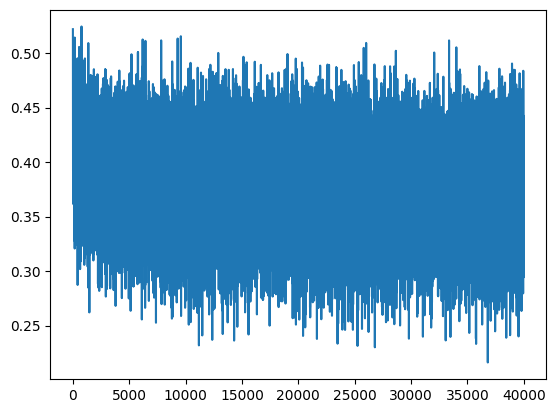

In [247]:
plt.plot(losses)

In [248]:
avg_loss = torch.tensor(losses).view(-1, 1000).mean(1)
avg_loss.shape

torch.Size([40])

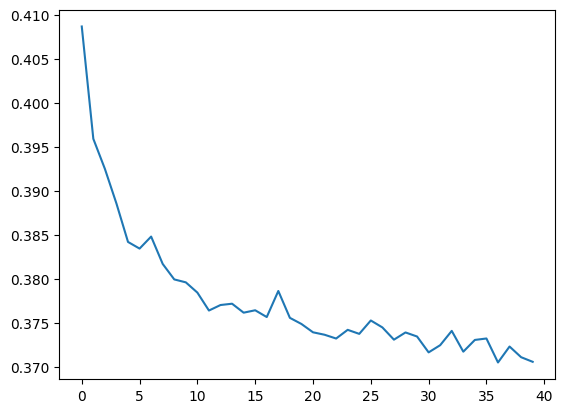

In [249]:
plt.plot(avg_loss)

### Evaluate on dev data

In [250]:
logits = model3(dev) # batch_size x 3 x 2
loss = F.cross_entropy(logits, dev_output)
print(f'loss={loss.item()}')

loss=2.3546903133392334


### Visualize the character embeddings

In [254]:
embeddings = model3.embed.weight.data
embeddings[:,0], embeddings[:,1]

(tensor([-0.2406,  0.6666, -0.5065, -0.1615, -0.3538,  0.9434, -0.4369, -0.2231,
         -0.1602,  0.6419, -0.5813, -0.2939,  0.1185, -0.6509,  0.0851,  0.5168,
         -0.3854, -0.0860, -0.1718, -0.0636, -0.2270,  0.5887, -0.4797, -0.1418,
         -0.0485,  0.7617, -0.3925]),
 tensor([ 0.4597,  0.3956, -0.1445, -0.0896, -0.3358,  0.1334, -0.3525, -0.0824,
         -0.4217, -0.1583, -0.8760, -0.3363, -1.7121, -0.4278, -0.6800,  0.2170,
         -0.0779, -6.3122, -0.9183, -0.0875, -0.1773,  0.0250, -0.4721, -0.3161,
         -0.3219, -0.3902, -0.4450]))

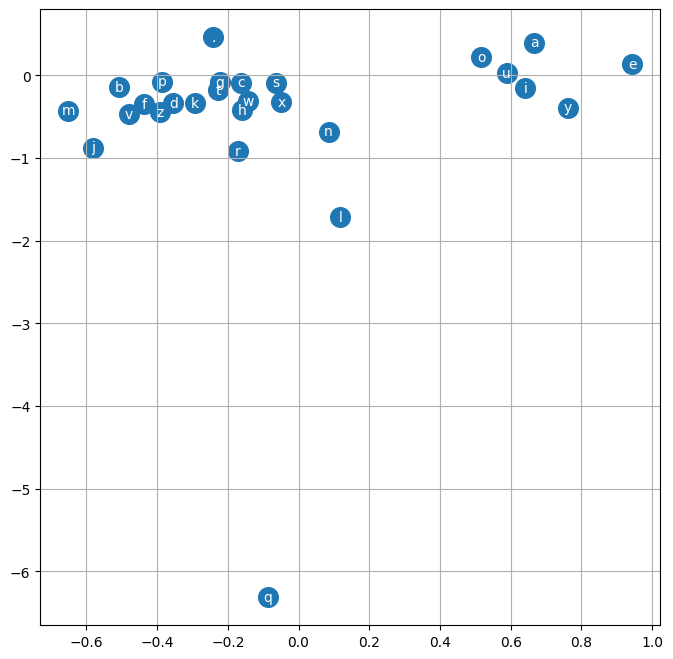

In [255]:
embeddings = model3.embed.weight.data

# Andrej Karpathy's scatter plot to visualize the 2D embeddings
plt.figure(figsize=(8,8))
plt.scatter(embeddings[:,0], embeddings[:,1], s=200)
for i in range(embeddings.shape[0]):
    plt.text(embeddings[i,0].item(), embeddings[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

### Sample from MLP n-gram model

In [256]:
model3

NgramMLP(
  (embed): Embedding(27, 2)
  (hidden): Linear(in_features=6, out_features=100, bias=True)
  (predict): Linear(in_features=100, out_features=27, bias=True)
)

In [257]:
stoi['.']

0

In [260]:
num_words = 20
prompt = '.'

g = torch.Generator().manual_seed(42)
for i in range(num_words):
    out = [prompt]
    context = [stoi[prompt]] * block_size
    while True:
        logits = model3(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [idx]
        out.append(itos[idx])
        if idx == stoi[prompt]:
            break
    print(''.join(out))

.anugeen.
.tis.
.mabian.
.dan.
.shan.
.silayley.
.kemarle.
.man.
.epiacholeilanzi.
.kerchio.
.ber.
.graela.
.mimonyjaya.
.vahia.
.achalan.
.tiar.
.tphelima.
.jach.
.selari.
.kuka.


## Original Source Code

The original source for this tutorial is available from Andrej Karpathy's github repo:

[makemore](https://github.com/karpathy/makemore/blob/master/makemore.py)

The original source code is a lot more low level and avoids many Pytorch conveniences which are embraced by this tutorial. As a result, the code will look quite different even though the overall structure follows the tutorial as laid out by Andrej in [his youtube video](https://www.youtube.com/watch?v=TCH_1BHY58I).

## End

In [236]:
from IPython.core.display import HTML

def css_styling():
    styles = open("../css/notebook.css", "r").read()
    return HTML(styles)
css_styling()